In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score



In [ ]:

# ---------------------------
# 1) PROJECT OVERVIEW (for IPD narrative)
# ---------------------------
print("""
PROJECT OVERVIEW (summary you can reuse in your IPD write-up):
- Goal: Segment NBA players into distinct playstyle groups using 2019–2020 playtype stats.
- Why: Clustering reveals archetypes (e.g., iso-heavy scorers, spot-up specialists, PnR creators),
  which can support scouting, roster construction, and matchup preparation.
- Output Prototype: Clustered player table + cluster profiles + PCA visualisations.
""")


PROJECT OVERVIEW (summary you can reuse in your IPD write-up):
- Goal: Segment NBA players into distinct playstyle groups using 2019–2020 playtype stats.
- Why: Clustering reveals archetypes (e.g., iso-heavy scorers, spot-up specialists, PnR creators),
  which can support scouting, roster construction, and matchup preparation.
- Output Prototype: Clustered player table + cluster profiles + PCA visualisations.



In [ ]:
# ---------------------------
# 2) LOAD DATA
# ---------------------------
DATA_PATH = "/content/player_style_clusters_2019_2020_output.csv"
df = pd.read_csv(DATA_PATH)

print("Loaded dataset shape:", df.shape)
display(df.head())
print("\nColumns:\n", df.columns.tolist())


Loaded dataset shape: (207, 20)


,player,team,iso_freq,transition_freq,pnr_handler_freq,pnr_rollman_freq,postup_freq,spotup_freq,handoff_freq,cut_freq,iso_ppp,transition_ppp,pnr_handler_ppp,pnr_rollman_ppp,postup_ppp,spotup_ppp,handoff_ppp,cut_ppp,cluster_kmeans,cluster_gmm
0,James Harden,HOU,0.450,0.199,0.179,0.000,0.000,0.049,0.027,0.016,1.12,1.10,0.98,0.00,0.00,1.26,1.14,1.32,0,0
1,Russell Westbrook,OKC,0.250,0.245,0.124,0.000,0.090,0.146,0.016,0.024,0.87,1.01,0.93,0.00,0.80,0.88,0.89,1.07,0,0
2,Damian Lillard,POR,0.179,0.097,0.517,0.000,0.000,0.050,0.050,0.014,1.07,1.17,1.15,0.00,0.00,1.19,1.09,1.16,0,0
3,Lebron James,LAL,0.175,0.195,0.273,0.008,0.101,0.062,0.037,0.033,0.90,1.13,0.99,1.08,0.97,1.01,0.72,1.40,0,0
4,Luka Doncic,DAL,0.150,0.108,0.463,0.000,0.034,0.061,0.054,0.017,1.02,0.96,1.04,0.00,1.02,0.93,1.03,1.47,0,0



Columns:
 ['player', 'team', 'iso_freq', 'transition_freq', 'pnr_handler_freq', 'pnr_rollman_freq', 'postup_freq', 'spotup_freq', 'handoff_freq', 'cut_freq', 'iso_ppp', 'transition_ppp', 'pnr_handler_ppp', 'pnr_rollman_ppp', 'postup_ppp', 'spotup_ppp', 'handoff_ppp', 'cut_ppp', 'cluster_kmeans', 'cluster_gmm']


In [ ]:
# Identifier columns
id_cols = ["player", "team"]

for c in id_cols:
    if c not in df.columns:
        raise ValueError(
            f"Expected identifier column '{c}' not found. "
            f"Available columns: {df.columns.tolist()}"
        )

# Numeric features (exclude existing cluster labels)
numeric_cols = [
    c for c in df.select_dtypes(include=["number"]).columns
    if not c.startswith("cluster")
]

X = df[numeric_cols].copy()
print("Numeric features used for clustering:", numeric_cols)


Numeric features used for clustering: ['iso_freq', 'transition_freq', 'pnr_handler_freq', 'pnr_rollman_freq', 'postup_freq', 'spotup_freq', 'handoff_freq', 'cut_freq', 'iso_ppp', 'transition_ppp', 'pnr_handler_ppp', 'pnr_rollman_ppp', 'postup_ppp', 'spotup_ppp', 'handoff_ppp', 'cut_ppp']


In [ ]:
# ---------------------------
# 4) FEATURE SET FOR CLUSTERING
# ---------------------------
# We cluster on numeric playtype stats only (freq + pts columns)
X = df[numeric_cols].copy()

print("\nNumber of numeric features used:", X.shape[1])
display(X.head())

# Standardize features (K-Means requires scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Number of numeric features used: 16


,iso_freq,transition_freq,pnr_handler_freq,pnr_rollman_freq,postup_freq,spotup_freq,handoff_freq,cut_freq,iso_ppp,transition_ppp,pnr_handler_ppp,pnr_rollman_ppp,postup_ppp,spotup_ppp,handoff_ppp,cut_ppp
0,0.450,0.199,0.179,0.000,0.000,0.049,0.027,0.016,1.12,1.10,0.98,0.00,0.00,1.26,1.14,1.32
1,0.250,0.245,0.124,0.000,0.090,0.146,0.016,0.024,0.87,1.01,0.93,0.00,0.80,0.88,0.89,1.07
2,0.179,0.097,0.517,0.000,0.000,0.050,0.050,0.014,1.07,1.17,1.15,0.00,0.00,1.19,1.09,1.16
3,0.175,0.195,0.273,0.008,0.101,0.062,0.037,0.033,0.90,1.13,0.99,1.08,0.97,1.01,0.72,1.40
4,0.150,0.108,0.463,0.000,0.034,0.061,0.054,0.017,1.02,0.96,1.04,0.00,1.02,0.93,1.03,1.47


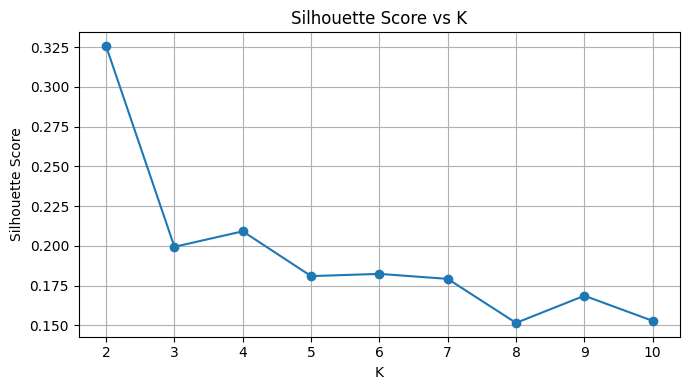

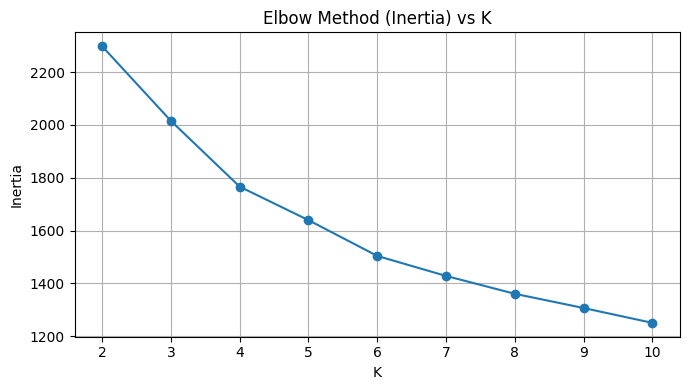


Selected K (highest silhouette): 2  |  silhouette=0.326


In [ ]:
# ---------------------------
# 5) CHOOSING K (Silhouette + Inertia “elbow”)
# ---------------------------
k_values = range(2, 11)
sil_scores = []
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Plot Silhouette
plt.figure(figsize=(7, 4))
plt.plot(list(k_values), sil_scores, marker="o")
plt.title("Silhouette Score vs K")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Inertia (Elbow)
plt.figure(figsize=(7, 4))
plt.plot(list(k_values), inertias, marker="o")
plt.title("Elbow Method (Inertia) vs K")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.grid(True)
plt.tight_layout()
plt.show()

best_k = list(k_values)[int(np.argmax(sil_scores))]
print(f"\nSelected K (highest silhouette): {best_k}  |  silhouette={max(sil_scores):.3f}")

In [ ]:
# ---------------------------
# 6) FINAL MODEL: K-MEANS (ONE MODEL)
# ---------------------------
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("\nCluster sizes:")
display(df["Cluster"].value_counts().sort_index())


Cluster sizes:


,count
Cluster,
0,154
1,53


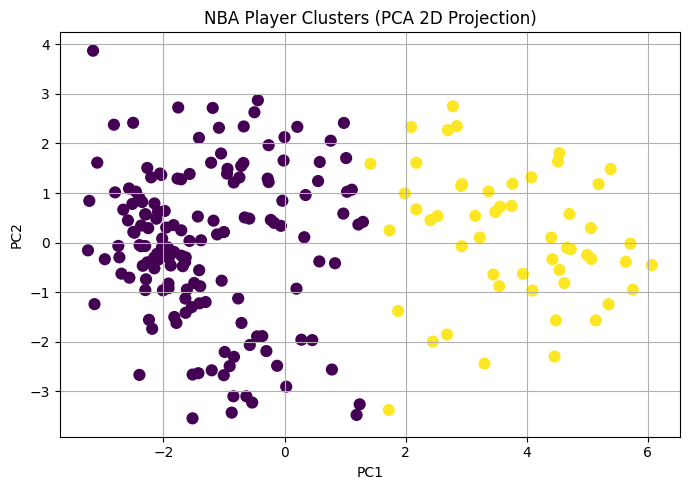


PCA explained variance ratio: [0.38430706 0.13851485]


In [ ]:
# ---------------------------
# 7) PROTOTYPE VISUALISATION: PCA (2D)
# ---------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Cluster"], s=60)
plt.title("NBA Player Clusters (PCA 2D Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nPCA explained variance ratio:", pca.explained_variance_ratio_)

In [ ]:
# =========================
# 8) CLUSTER PROFILING (Interpretation-ready tables)
# =========================

# Mean feature values per cluster
cluster_profile = df.groupby("Cluster")[feature_cols].mean().round(4)

print("\nCluster profile (mean feature values):")
display(cluster_profile)

# ---- Standout features per cluster using z-scores ----
overall_mean = df[feature_cols].mean()
overall_std = df[feature_cols].std().replace(0, np.nan)

cluster_z = (cluster_profile - overall_mean) / overall_std
cluster_z = cluster_z.replace([np.inf, -np.inf], np.nan)

print("\nTop 6 standout features per cluster (higher z = more characteristic):")
for c in sorted(df["Cluster"].unique()):
    top_feats = (
        cluster_z.loc[c]
        .sort_values(ascending=False)
        .head(6)
    )
    print(f"\nCluster {c} standout features:")
    display(top_feats.to_frame("z_score").round(2))



Cluster profile (mean feature values):


,iso_freq,transition_freq,pnr_handler_freq,pnr_rollman_freq,postup_freq,spotup_freq,handoff_freq,cut_freq,iso_ppp,transition_ppp,pnr_handler_ppp,pnr_rollman_ppp,postup_ppp,spotup_ppp,handoff_ppp,cut_ppp
Cluster,,,,,,,,,,,,,,,,
0,0.0698,0.1748,0.2390,0.0157,0.0241,0.2288,0.0630,0.0397,0.7448,1.0937,0.8719,0.4005,0.3165,1.0423,0.8703,1.0886
1,0.0264,0.1026,0.0053,0.1930,0.1258,0.1607,0.0048,0.1479,0.4252,1.2100,0.1340,1.1711,0.7975,0.8291,0.1358,1.2774



Top 6 standout features per cluster (higher z = more characteristic):

Cluster 0 standout features:


,z_score
pnr_handler_ppp,0.48
handoff_ppp,0.42
pnr_handler_freq,0.37
handoff_freq,0.34
transition_freq,0.33
spotup_ppp,0.22



Cluster 1 standout features:


,z_score
pnr_rollman_freq,1.48
cut_freq,1.16
postup_freq,1.03
pnr_rollman_ppp,0.97
postup_ppp,0.77
transition_ppp,0.49


In [ ]:
# ---------------------------
# 9) EXPORT ARTIFACTS (EVIDENCE FOR IPD DEMO VIDEO)
# ---------------------------
# Save the clustered dataset for your appendix / prototype evidence
output_csv = "nba_playtype_clustered_2019_2020.csv"
df.to_csv(output_csv, index=False)

# Save the cluster profile too
profile_csv = "nba_cluster_profiles.csv"
cluster_profile.to_csv(profile_csv)

print(f"\nSaved outputs:\n- {output_csv}\n- {profile_csv}")


Saved outputs:
- nba_playtype_clustered_2019_2020.csv
- nba_cluster_profiles.csv


In [ ]:
# ---------------------------
# 10) METHOD CHALLENGES + NEXT PLAN (prints you can reuse)
# ---------------------------
print("""
METHODOLOGICAL CHALLENGES (talking points):
- Feature scaling was necessary because K-Means is distance-based.
- The dataset had ambiguous duplicate naming ('p&rr-pts' vs 'p&rr-pts.1'); we validated ranges
  and renamed to 'p&rr-freq' and 'p&rr-pts' to avoid misinterpretation.
- K selection is subjective; we used silhouette + elbow to justify chosen K.

OUTSTANDING TASKS / PLAN (if you need next steps):
- Label clusters with human-readable archetype names (e.g., 'Iso Creators', 'Spot-up Wings').
- Validate cluster stability (run different random seeds / bootstrap samples).
- Add a simple dashboard/table view (filter by team, cluster, top metrics) for a stronger prototype demo.
""")


METHODOLOGICAL CHALLENGES (talking points):
- Feature scaling was necessary because K-Means is distance-based.
- The dataset had ambiguous duplicate naming ('p&rr-pts' vs 'p&rr-pts.1'); we validated ranges
  and renamed to 'p&rr-freq' and 'p&rr-pts' to avoid misinterpretation.
- K selection is subjective; we used silhouette + elbow to justify chosen K.

OUTSTANDING TASKS / PLAN (if you need next steps):
- Label clusters with human-readable archetype names (e.g., 'Iso Creators', 'Spot-up Wings').
- Validate cluster stability (run different random seeds / bootstrap samples).
- Add a simple dashboard/table view (filter by team, cluster, top metrics) for a stronger prototype demo.

